* ## New York City Taxi Ride Duration - Ridge Regression Modeling
* **By Abdallah Hashem**


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')


## 2. Load Data
We load `train.csv` and `val.csv` **separately** and keep them separate all the way through, so the exact same cleaning/encoding function is applied to both without any leakage between them.


In [2]:
train_df = pd.read_csv(r"C:\Users\Abdullah\PyCharmMiscProject\ML\Project_trip\Data\split\train.csv")
val_df = pd.read_csv(r"C:\Users\Abdullah\PyCharmMiscProject\ML\Project_trip\Data\split\val.csv")

print('Train shape:', train_df.shape)
print('Val shape:', val_df.shape)


Train shape: (1000000, 10)
Val shape: (229319, 10)


## 3. Cleaning & Feature Engineering Function
This packages every step from the EDA notebook (outlier removal, log transform, haversine distance, date/time features, dropping leaked/unused columns) into a single function so it's applied **identically** to train and val.


In [3]:
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6367 * c


RUSH_HOURS = [7, 8, 9, 16, 17, 18, 19]


def clean_and_engineer(df):
    df = df.copy()

    # --- basic cleaning ---
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)

    # --- passenger_count outliers ---
    df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)].copy()

    # --- trip_duration outliers (< 1 min or > 2 hours) ---
    df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 7200)].copy()

    # --- target: log-transformed duration ---
    df['target_log_duration'] = np.log1p(df['trip_duration'])

    # --- distance feature ---
    df['distance_km'] = haversine_distance(
        df['pickup_longitude'], df['pickup_latitude'],
        df['dropoff_longitude'], df['dropoff_latitude']
    )

    # remove near-zero-distance trips (likely bad GPS / data errors, pure noise for a linear model)
    df = df[df['distance_km'] > 0.05].copy()

    # log-transform distance too (it's right-skewed just like duration)
    df['distance_km_log'] = np.log1p(df['distance_km'])

    # --- date/time features ---
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['pickup_month'] = df['pickup_datetime'].dt.month
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
    df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(int)
    df['is_rush_hour'] = df['pickup_hour'].isin(RUSH_HOURS).astype(int)

    bins = [0, 2, 5, 8, 11, 12]
    labels = ['Winter', 'Spring', 'Summer', 'Autumn', 'Winter']
    df['pickup_Season'] = pd.cut(df['pickup_month'], bins=bins, labels=labels, ordered=False)
    df['time_period'] = df['pickup_hour'].apply(
        lambda h: 'Morning' if 5 <= h < 12 else 'Afternoon' if 12 <= h < 17
        else 'Evening' if 17 <= h < 21 else 'Night'
    )

    # --- cyclic encoding for hour & day-of-week (these are circular, not linear) ---
    df['hour_sin'] = np.sin(2 * np.pi * df['pickup_hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['pickup_hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['pickup_dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['pickup_dayofweek'] / 7)

    # --- interaction term: distance matters more during rush hour traffic ---
    df['distance_x_rush_hour'] = df['distance_km_log'] * df['is_rush_hour']

    # --- drop leakage / raw / unused / now-encoded columns ---
    df.drop(columns=[
        'trip_duration', 'pickup_datetime',
        'pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude',
        'distance_km', 'pickup_hour', 'pickup_dayofweek'
    ], inplace=True)

    # --- encoding ---
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': 1, 'N': 0})
    df = pd.get_dummies(df, columns=['vendor_id', 'pickup_Season', 'time_period'], drop_first=True)

    return df


## 4. Apply Cleaning & Align Columns
One-hot encoding can produce slightly different columns between train and val if a category is missing in one of them. We fix that by aligning val's columns to train's columns (filling any missing ones with 0).


In [4]:
train_clean = clean_and_engineer(train_df)
val_clean = clean_and_engineer(val_df)

# align val columns to train columns (handles any one-hot mismatch)
val_clean = val_clean.reindex(columns=train_clean.columns, fill_value=0)

print('Train shape after cleaning:', train_clean.shape)
print('Val shape after cleaning:', val_clean.shape)

train_clean.head()


Train shape after cleaning: (988275, 19)
Val shape after cleaning: (226618, 19)


,passenger_count,store_and_fwd_flag,target_log_duration,distance_km_log,pickup_month,is_weekend,is_rush_hour,hour_sin,hour_cos,dow_sin,dow_cos,distance_x_rush_hour,vendor_id_2,pickup_Season_Spring,pickup_Season_Summer,pickup_Season_Winter,time_period_Evening,time_period_Morning,time_period_Night
0,1,0,6.947937,1.324769,6,0,1,9.659258e-01,-0.258819,0.974928,-0.222521,1.324769,True,False,True,False,False,True,False
1,1,0,6.719013,1.084496,4,1,0,1.224647e-16,-1.000000,-0.781831,0.623490,0.000000,True,True,False,False,False,False,False
2,5,0,6.421622,0.877088,6,1,0,5.000000e-01,0.866025,-0.781831,0.623490,0.000000,True,False,True,False,False,False,True
3,2,0,6.766192,1.091056,5,0,1,-9.659258e-01,-0.258819,0.433884,-0.900969,1.091056,True,True,False,False,True,False,False
4,4,0,8.510773,3.083041,5,0,1,-9.659258e-01,-0.258819,0.433884,-0.900969,3.083041,False,True,False,False,True,False,False


## 5. Split Features (X) and Target (y)


In [5]:
X_train = train_clean.drop(columns=['target_log_duration'])
y_train = train_clean['target_log_duration']

X_val = val_clean.drop(columns=['target_log_duration'])
y_val = val_clean['target_log_duration']

print('X_train:', X_train.shape, ' X_val:', X_val.shape)


X_train: (988275, 18)  X_val: (226618, 18)


## 6. Ridge Regression Pipeline (Polynomial Features + Scaling + RidgeCV)

We apply **degree-2 polynomial features** only to the strongest numeric drivers (`distance_km_log`, `hour_sin`, `hour_cos`, `distance_x_rush_hour`) so Ridge can capture curvature and interactions (e.g. distance² effects, distance x rush-hour) without exploding the feature space by squaring every column. The rest of the features (categoricals, flags) pass through unchanged. `StandardScaler` is applied throughout since Ridge is scale-sensitive, and `RidgeCV` searches over `alpha` via cross-validation on the training set.


In [6]:
poly_features = ['distance_km_log', 'hour_sin', 'hour_cos', 'distance_x_rush_hour']
other_features = [c for c in X_train.columns if c not in poly_features]

preprocessor = ColumnTransformer([
    ('poly', Pipeline([
        ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('scale_poly', StandardScaler())
    ]), poly_features),
    ('scale_other', StandardScaler(), other_features)
])

alphas = np.logspace(-3, 3, 20)

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', RidgeCV(alphas=alphas, cv=5 ))
])

ridge_pipeline.fit(X_train, y_train)

print('Best alpha:', ridge_pipeline.named_steps['ridge'].alpha_)


Best alpha: 2.976351441631316


## 7. Evaluate on Validation Set
RMSE/MAE here are on the log scale, which is equivalent to RMSLE/MALE on the original trip_duration scale (a metric well suited to right-skewed duration data).


In [7]:
preds = ridge_pipeline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
mae = mean_absolute_error(y_val, preds)
r2 = r2_score(y_val, preds)

print(f'RMSE (log scale): {rmse:.4f}')
print(f'MAE  (log scale): {mae:.4f}')
print(f'R\u00b2 score:        {r2:.4f}')


RMSE (log scale): 0.4074
MAE  (log scale): 0.3114
R² score:        0.6859


## 8. Inspect Coefficients
Useful for checking which features matter most, and for judging whether `pickup_month` and `pickup_Season` are both pulling their weight or one is redundant.


In [8]:
# Feature names after ColumnTransformer + PolynomialFeatures
poly_names = ridge_pipeline.named_steps['preprocessor'].named_transformers_['poly']\
    .named_steps['poly_features'].get_feature_names_out(poly_features)
all_feature_names = list(poly_names) + other_features

coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': ridge_pipeline.named_steps['ridge'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df


,feature,coefficient
0,distance_km_log,1.020560
4,distance_km_log^2,-0.461559
2,hour_cos,-0.140558
1,hour_sin,-0.064893
27,time_period_Night,0.051364
20,dow_cos,-0.041148
25,time_period_Evening,0.039948
16,pickup_month,0.039573
8,hour_sin^2,-0.030093
11,hour_cos^2,0.030093


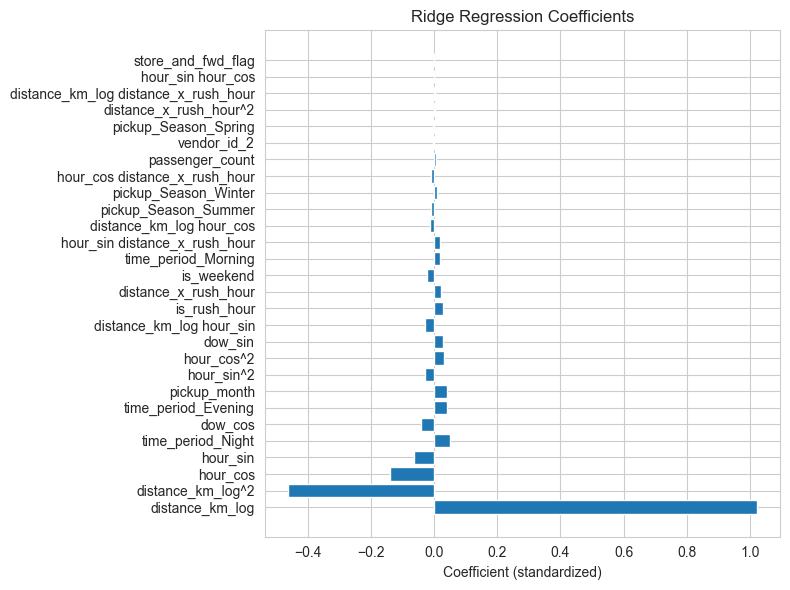

In [9]:
plt.figure(figsize=(8, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel('Coefficient (standardized)')
plt.title('Ridge Regression Coefficients')
plt.tight_layout()
plt.show()


## 9. Actual vs Predicted (Validation)


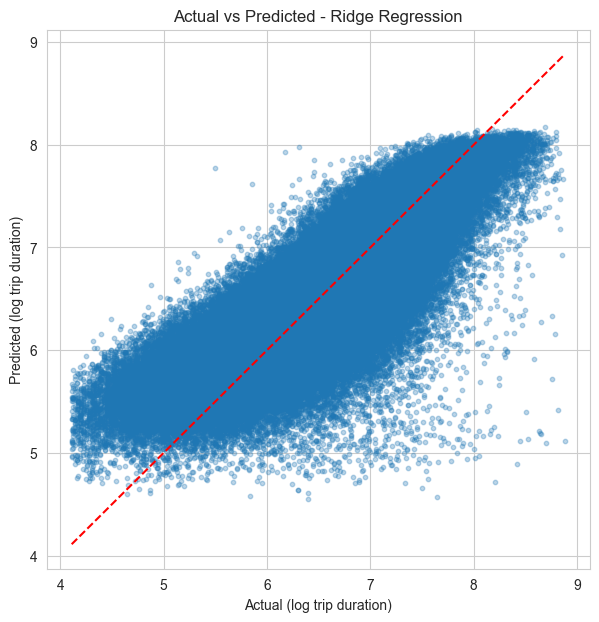

In [10]:
plt.figure(figsize=(7, 7))
plt.scatter(y_val, preds, alpha=0.3, s=10)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual (log trip duration)')
plt.ylabel('Predicted (log trip duration)')
plt.title('Actual vs Predicted - Ridge Regression')
plt.show()
